<h1 style="text-align: center;">ANÁLISIS Y PROCESAMIENTO DE SEÑALES</h1>

<center>
    
### 1er cuatrimestre 2026
</center>

<p style="text-align: center;">Muñoz Jazmín Ayelén</p>

<h3 style="text-align;">INTRODUCCIÓN</h3>

En esta tarea semanal, se produce un cambio significativo respecto a las anteriores, debido a que se deja de trabajar con señales simuladas en el código $(sin(2*pi*f*t))$  y se procede a operar con señales reales. 

El análisis espectral de señales en el mundo real, presenta desafíos diferentes en comparación al estudio de las señales determinísticas con las que se trabajaba anteriormente. La señal ideal, simulada en el código, posee parámetros fijos y conocidos, mientras que por su parte las señales biológicas y acústicas con las que se trabajará en esta tarea, tienen una naturaleza no determinínistica o estocástica. Estas señales no pueden describirse mediante una ecuación analítica exacta, sino que deben tratarse como procesos aleatorios que se acoplan a diversas fuentes de ruido térmico, como por ejemplo la interferencia de la línea de alimentación, (cuando se estudiaron los filtros, se llegó a que esta es de $50\text{ Hz}$ ) o a bajas frecuecnias provocadas por la respiración o el movimiento del sujeto. 

Para estudiar cómo se distribuye la potencia de estas señales en torno a la frecuencia, se debe estimar la densidad espectral de potencia, la cual se define como la DFT de la función de autocorrelación donde se asume un registro infinito, sin embargo, en la práctica solo se tiene un registro finito de $N$ muestras, se usa la aproximación del periodograma de Schuster, es decir el módulo al cuadrado de la DFT dividido por la cantidad de muestras, sin embargo esto presenta un problema, ya que se trata de un estimador estadísticamente no consisente.  

Debido al ruido aleatorio, el espectro resultante presenta una varianza muy elevada visualmente, dando un aspecto "serruchado", e incluso si aumentamos la cantidad de muestras $N$ , la varianza no disminuye, solo se agregan más puntos al gráfico, sin aplanar el ruido.  

Para subsanar estas limitaciones, en esta tarea se implementarán métodos de estimación espectral no paramétricos, es decir, que no se asume que la señal responda a algún modelo matemático ya conocido ni se presupone nada de la señal.  

**1. PERIODOGRAMA VENTANEADO:**

Consiste en multiplicar la señal por una función de ventana previamente a calcular la FFT, básicamente el procedimiento que se realizó en la tarea semanal anterior, esto suaviza los bordes del registro, disminuyendo el spectral leakage a cambio de un leve ensanchamiento del lóbulo principal, es decir que disminuye la resolución.

**2. MÉTODO DE WELCH:**

Ese algoritmo tiene una estrategia basad en el promedio estadístico, en lugar de procesar todas las muestras de la señal de golpe, lo divide en varios bloques cortos que se superponen entre sí, para no perder la información en los cortes. A cada uno de los bloques se les aplica una ventana de atenuación para suavizar los extremos, eliminando las frecuencias falsas, luefo se calcula el espectro individual en cada uno de los pedacitos.

Finalmente, se promedian los espectros de todos los bloques, esto es fundamental, ya que los picos aleatorios del ruido, tienden a cancelarse entre sí, dando como resultado una reducción de la varianza, donde ese gráfico serruchado se transforma en una curva suave que demuestra la verdadera distribución de la potencia de la señal.

**3. BLACKMAN-TUKEY:**

Mientras que el método de Welch tomaba la señal y la diseccionaba en partes para luego calcularle la FFT, Blackman-Tukey apunta directo a la definición teórica de la DSP que se mencionó al inicio, calcula la autocorrelación estimada $\hat{R}_{xx}(k)$, al calcular la autocorrelación para desplazamientos grandes, las  muestras son pocas y se superponen, dando valores muy ruidosos, por lo que se aplica una ventana de Blackman o Hamming en la función de autocorrelación, mandando a cero los lags grandes donde solo hay ruidos. Finalmente, a esa autocorrelación limpia y ventaneada se le aplica la FFT. 

Gracias a estas herramientas, en este trabajo, se procesarán registros reales de ECG, PPG y señales de audio, con el fin de estimar sus PSDs  y a partir de dichas estimaciones, se procederá a calcular el ancho de banda efectivo de cada uno de estos fenómenos. 

<h3 style="text-align;">CONSIGNAS</h3>

Siendo las señales: 
- Electrocardiograma (ECG). En el archivo ECG_TP4.mat encontrará un registro electrocardiográfico (ECG)
- Pletismografía (PPG). El archivo PPG.csv contiene una señal registrada en reposo de un estudiante de la materia que ha donado su registro.
- Audio. Tres registros en los que el profesor pronuncia una frase, y otros dos en los que se silba una melodía muy conocida.

1.  Realizar la estimación de la densidad espectral de potencia (PSD) de cada señal mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey).

2) Realice una estimación del ancho de banda de cada señal y presente los resultados en un tabla para facilitar la comparación.



<h3 style="text-align;">RESOLUCIÓN</h3>

Como el objetivo de esta Ts consiste en analizar y aprender sobre como estos métodos procesan señales reales, pese a ser caóticas y ruidosas, para observar su distribución de potencia en torno a la frecuencia, se utilizarán las señales ruidosas, sin procesar previamente. 

**1. MÉTODO DE WELCH:**

**LECTURA DE LAS SEÑALES USANDO COMO GUÍA EL ARCHIVO DEL PROFE MARIANO**

In [2]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio #Importo esta librería para los .mat 

#  Leo la señal del Electrocardiograma (ECG)
fs_ecg = 1000 #Definición de la frecuencia de muestreo del ECG.
mat_struct = sio.loadmat('./ECG_TP4.mat') #Lee el archivo binario de Matlab, y devuelve un diccionario en Python. 
ecg_lead = mat_struct['ecg_lead'].flatten() #Accede al diccionario  bsucando ecg_lead. 
#Esto no me funciona sin el flatten, no me andaba, se lo puse a la ia y solo le agregó eso,
#entendí que tiene que ver con que las funciones que vamos a usar esperan un vector plano y no una matriz, flatten hace eso, me lo aplana en un 
#solo array de una sola fila. 

# Leo la señal Pletismografía (PPG) 
fs_ppg = 400 # Hz
ppg_raw = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1) #Es una función de NumPy diseñada para leer archivos de texto  que contienen 
# datos numéricos, skip_header=1 salta la primera línea que suele ser un título, así no se rompe al intentar leerlo como número.  
#delimiter=',' avisa que el carácter que separa un número del siguiente en el archivo es una coma.


# Leo los archivos de Audio.
fs_audio1, wav_cucaracha = sio.wavfile.read('la cucaracha.wav') 
fs_audio2, wav_prueba    = sio.wavfile.read('prueba psd.wav')
fs_audio3, wav_silbido   = sio.wavfile.read('silbido.wav')
# sio.wavfile.read es una función  para decodificar archivos de audio  .wav , devuelve una tupla, la frecuencia de muestreo y las amplitudes de onda. 

**CÁLCULO DE LA ESTIMACIÓN DE LAS DENSIDADES POTENCIA USANDO EL MÉTODO DE WELCH**

In [3]:
# 1. ECG 
f_ecg, Pxx_ecg = sig.welch(ecg_lead, fs_ecg, nperseg=1024)
#Aplico el método de Welch, tiene tres elementos de entrada: ecg_lead es el vector temporal de datos, fs_ecg  la frecuencia de muestreo
#para que pueda ajustar el eje de frecuencias y nperseg=1024: Longitud de cada segmento en cantidad de muestras. 
#Al no especificar el tipo de ventana ni la superposición se aplica por defecto una ventana de Hann y un solapamiento del 50% 
#Devuelve dos salidas, f_ecg es un vector que contiene los componentes de frcuencias, va desde 0 hatsa nyquist (fs/2) 
# y Pxx_ecg es el vector que contiene los valores estimados de la Densidad Espectral de Potencia.

Pxx_ecg_db = 10 * np.log10(Pxx_ecg) #hago una transformación logarítmica a los valores de la PSD.

# 2. PPG
f_ppg, Pxx_ppg = sig.welch(ppg_raw, fs_ppg, nperseg=512)
Pxx_ppg_db = 10 * np.log10(Pxx_ppg)

#  3. Audio: La Cucaracha
f_cuca, Pxx_cuca = sig.welch(wav_cucaracha, fs_audio1, nperseg=4096)
Pxx_cuca_db = 10 * np.log10(Pxx_cuca)

# 4. Audio: Prueba PSD
f_prue, Pxx_prue = sig.welch(wav_prueba, fs_audio2, nperseg=4096)
Pxx_prue_db = 10 * np.log10(Pxx_prue)

# 5. Audio: Silbido 
f_silb, Pxx_silb = sig.welch(wav_silbido, fs_audio3, nperseg=4096)
Pxx_silb_db = 10 * np.log10(Pxx_silb)

**GRÁFICO DE LAS PSDs DE LAS 5 SEÑALES**

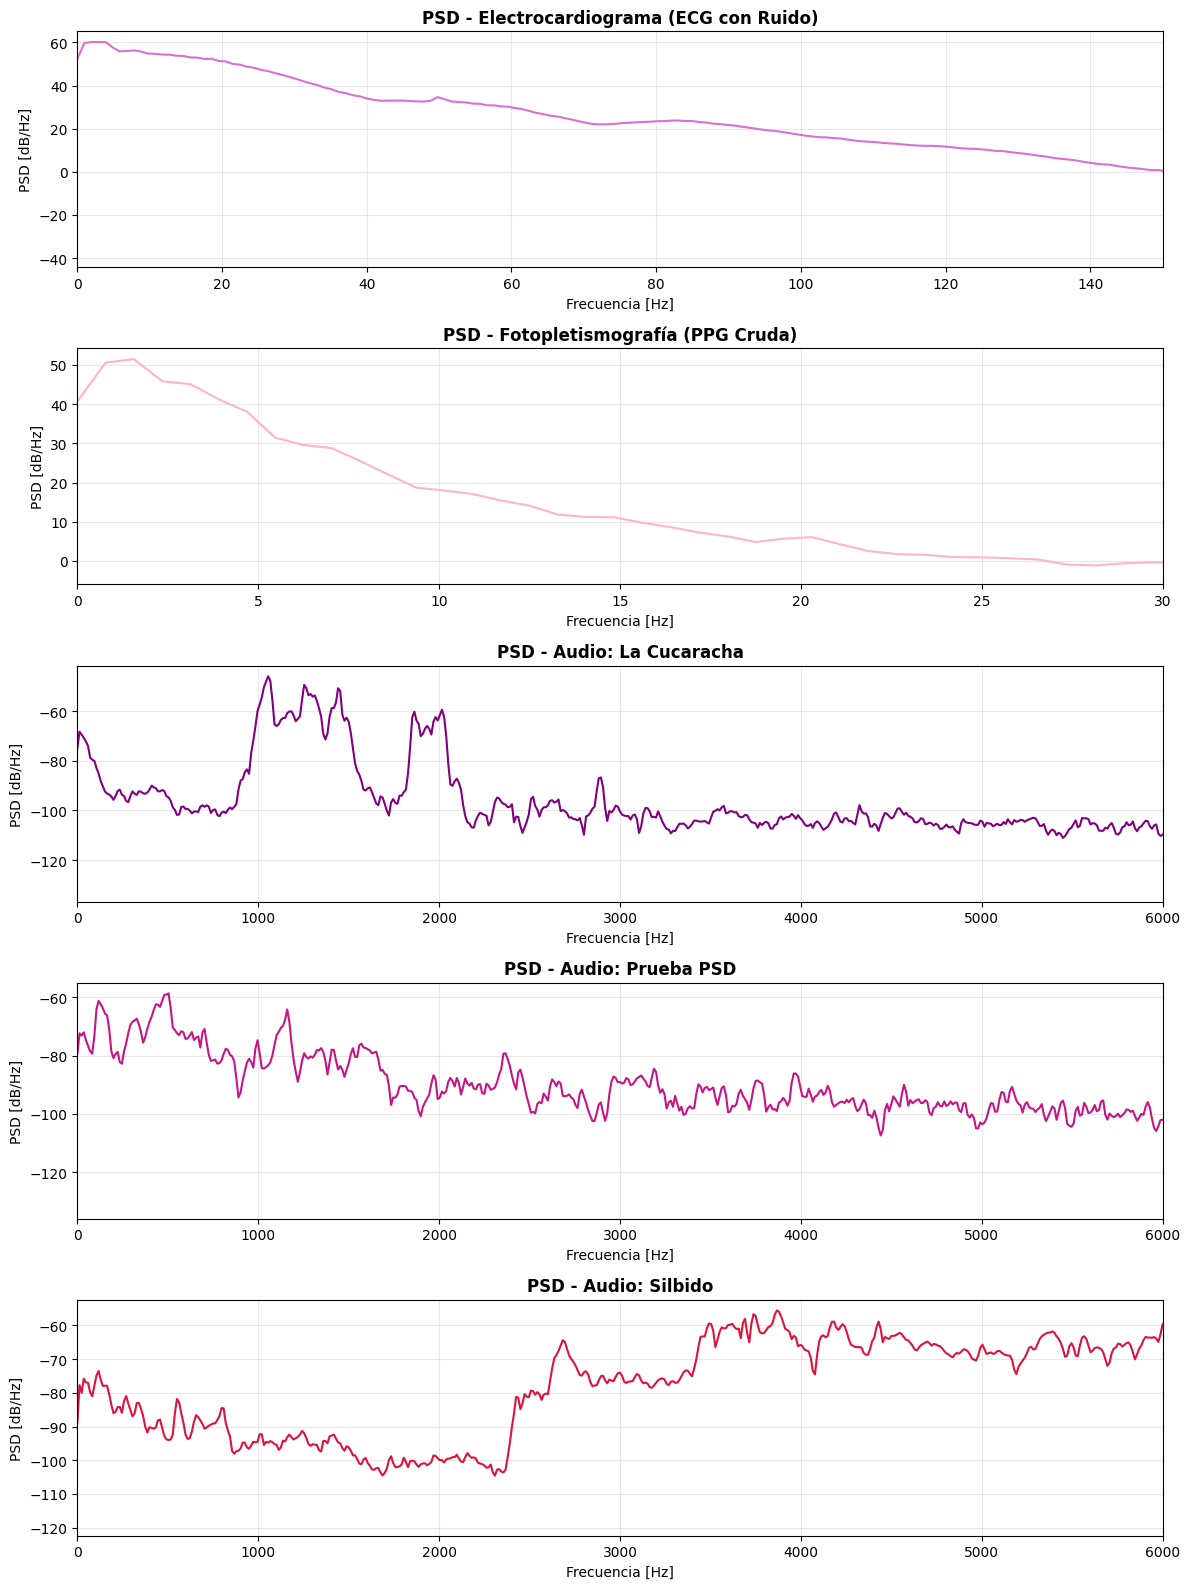

In [4]:
plt.figure(figsize=(12, 16))

# ECG
plt.subplot(5, 1, 1)
plt.plot(f_ecg, Pxx_ecg_db, color='orchid')
plt.title('PSD - Electrocardiograma (ECG con Ruido)', fontweight='bold') # fontweight='bold' me lo pone en negrita, porque entre tanto texto me pierdo.
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 150])
plt.grid(True, alpha=0.3)

# PPG
plt.subplot(5, 1, 2)
plt.plot(f_ppg, Pxx_ppg_db, color='lightpink')
plt.title('PSD - Fotopletismografía (PPG Cruda)', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 30])
plt.grid(True, alpha=0.3)

# Audio 1: La Cucaracha
plt.subplot(5, 1, 3)
plt.plot(f_cuca, Pxx_cuca_db, color='purple')
plt.title('PSD - Audio: La Cucaracha', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 6000])
plt.grid(True, alpha=0.3)

# Audio 2: Prueba PSD
plt.subplot(5, 1, 4)
plt.plot(f_prue, Pxx_prue_db, color='mediumvioletred')
plt.title('PSD - Audio: Prueba PSD', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 6000])
plt.grid(True, alpha=0.3)

# Audio 3: Silbido
plt.subplot(5, 1, 5)
plt.plot(f_silb, Pxx_silb_db, color='crimson')
plt.title('PSD - Audio: Silbido', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 6000])
plt.grid(True, alpha=0.3)

plt.tight_layout() #Me quedaban todos los títulos del gráfico superpuestos, Gemini me dijo que le agregue esto que lo que hace es acivar un 
#algoritmo de matplotlib que reajusta automáticamente las posiciones y los espacios entre los gráficoos, y ahí me quedó lindo.
plt.show()

La PSD es un gráfico que  muestra cómo se distribuye la potencia (o la energía) de una señal a lo largo de las distintas frecuencias, si se intentara calcular la FFT  directamente sobre un ruido infinito, la energía total de esa señal sería infinita, por lo que la integral de Fourier no convergería, sin embargo mediante la técnica de Welch, se puede obtener una idea de la distribución de la potencia de dichas señales. 

**1. Análisis del ECG**

La gran potencia útil se concentra en las frecuencias muy bajas, con pico máximo en torno a los $2\text{ Hz}$ a $5\text{ Hz}$ , esto coincide con la frecuencia de los complejos QRS, que representa la despolarización de los ventrículos del corazón, provocando su contracción y el bombeo de la sangre.

Luego, la energía decae progresivamente a medida que la frecuencia aumenta. Hay una zona de sumo interés, que ya se abordó en tareas anteriores, es en torno a los $50\text{ Hz}$ y consiste en la interferencia de la red eléctrica que se acopla a los cables de los electrodos conectados a los pacientes. Luego, la potencia decae brúscamente, y lo que queda en torno a los $150\text{ Hz}$ parece ser mayormente ruido de fondo. 

**2. Análisis de PPG**

Es un espectro similar al anterior, pero es aún más lento, el pico absoluto de pottencia está marcado antes de los $2.5\text{ Hz}$  y después de $1\text{ Hz}$, si se toma que es al rededor de $1.5\text{ Hz}$ y se lo multiplica por 60, para obtener las pulsaciones por minuto, eso da aproximadamente 90PPM, siendo lógico para alguien despierto sin exigencias. Pasados los $10\text{ Hz}$ la potencia decae casi hacia los 0dB. 

**3. Análisis de Audio de la cucaracha**

Se puede observar una diferencia clara respecto a las señales biológicas anteriores, que tenían su pico en las bajas frecuencias. En este caso, la energía de la señal acústica  se distribuye en una banda mucho más alta y ancha. Hay grandes zonas de energía, principalmente en  los $1000\text{ Hz}$ y los $1500\text{ Hz}$, luego hay otro bloque de picos más pequeñitos en torno a los $2000\text{ Hz}$. 

La zona plana pero picosita, en torno a los -105dB, es el piso de ruido, y se puede observar que pasando los $2300\text{ Hz}$ proximadamente, la potencia cae a esa zona, al igual que antes de los $1000\text{ Hz}$ , por lo que el ancho de banda útil parece estar lozalizado en dicha banda media. 

**4. Análisis de Audio: Prueba PSD**

A diferencia del anterior, este registro posee una distribución de energía más homogeneo en bajas frecuencias, el pico máximo arranca en torno a los 300 - 400 Hz, según internet la voz humana tiene una frecuencia fundamental que oscila entre los 100 y 300 Hz, por lo que se encuentra un poquito por arriba de lo esperado, esta se extiende en picos sucesivos hasta los  $1500\text{ Hz}$ aproximadamente, luefo decae al piso de ruido en torno a los -90dB, la potencia parece concentrarse entre los entre los $100\text{ Hz}$ y los $2000\text{ Hz}$.

**5. Análisis de Audio: Silbido**

Posee un comportamiento cuasiplano en torno a los  $-100\text{ dB}$ y lo mantiene hasta aproximadamente los $2400\text{ Hz}$, luego en esa frecuencia la enerfía pega un salto hasta los casi $-50/-40 dB$, manteniéndose en alto. Esto tiene sentido con el carácter físico de un silbido, que es una señal de alta frecuencia, son notas agudas, que se concentra en este caso, por encima de los $2500\text{ Hz}$ hasta los $5000\text{ Hz}$ aprox. Por debajo, se encuentra el piso de ruido, posiblemente del micrófono. Su ancho de banda, parece tener el carácter de un pasa alto. 

**2. MÉTODO DE BLACKMAN-TUKEY:**

**CREACIÓN DE LA FUNCIÓN QUE CALCULA LA DPSD POR EL MÉTODO DE BLACKMAN-TUKEY**

In [5]:
 #Me perdí un montón, porque busqué en spicy .signal cómo usarlo y terminé viendo la implementación en un foro, que usaba un millón  de cosas
    #que no vimos, así que hice medio un **Frankestein** entre eso y lo que me corrigió la IA. 

def blackman_tukey_psd(x, fs, max_lag): #Defino una función que me calcule la Psd usando Blackman-Tukey, así no tengo que hacer 5 veces lo mismo.
#  x es el vector que contiene las muestras de la señal ( ECG,  PPG , audio).
#  fs es la frecuencia de muestreo de esa señal en particular.
#  max_lag  es el parámetro que representa la cantidad máxima de desplazamientos en muestras, que se va inspeccionar en la autocorrelación.
    
    N = len(x) # Cueno cuántas muestras totales tiene el vector x y guardo ese número entero en N, para después dividir por N. 
    x_detrend = x - np.mean(x) # np.mean(x) Calcula el promedio de todos los valores de la señal y se lo resta a cada una de las muestras de x, 
    # guardando el resultado en  x_detrend, esto sirve para eliminar la componente de continua (DC) y que no me tape la info que quiero ver. 
    
    # AHORA VOY A USAR UN TRUCO PARA CALCULAR LA AUTOCORRELACIÓN USANDO LA FFT Y NO MOVIENDO LA SEÑAL MUESTRA A MUESTRA EN EL TIEMPO.
    
    # Llevamos a frecuencias completando con ceros (zero-padding) para evitar solapamiento circular
    n_fft = 2**int(np.ceil(np.log2(2 * N - 1)))
    X = np.fft.fft(x_detrend, n=n_fft)
    
    # La autocorrelación es la FFT inversa del módulo al cuadrado, según el teorema de Wiener-khinchin
    r_full = np.fft.ifft(X * np.conj(X)).real / N
    
    # acomodo el resultado para tener los lags negativos a la izquierda y positivos a la derecha
    r = np.concatenate((r_full[-(N-1):], r_full[:N]))
    centro = len(r) // 2
    
    # Tengo que acotar a los lags de interés (-max_lag a +max_lag)
    r_acotada = r[centro - max_lag : centro + max_lag + 1]
    
    # Ventaneo  la autocorrelación con una ventana de Hann
    w = sig.windows.hann(len(r_acotada))
    r_ventaneada = r_acotada * w
    
    # Hago la transformada de Fourier final sobre la autocorrelación
    Pxx = np.abs(np.fft.fft(r_ventaneada))
    f = np.fft.fftfreq(len(r_ventaneada), d=1/fs)
    
    # Me quedo solo con las frecuencias positivas.
    pos_indices = np.where(f >= 0)
    return f[pos_indices], Pxx[pos_indices]

**LLAMO A LA FUNCIÓN PARA LAS 5 SEÑALES**

In [6]:
# Uso la función pasándole a cada una su vector, su fs y su ventana (max_lag)
f_bt_ecg, Pxx_bt_ecg   = blackman_tukey_psd(ecg_lead, fs_ecg, max_lag=512)
f_bt_ppg, Pxx_bt_ppg   = blackman_tukey_psd(ppg_raw, fs_ppg, max_lag=256)
f_bt_cuca, Pxx_bt_cuca = blackman_tukey_psd(wav_cucaracha, fs_audio1, max_lag=2048)
f_bt_prue, Pxx_bt_prue = blackman_tukey_psd(wav_prueba, fs_audio2, max_lag=2048)
f_bt_silb, Pxx_bt_silb = blackman_tukey_psd(wav_silbido, fs_audio3, max_lag=2048)

**GRÁFICO DE LAS PSDs DE LAS 5 SEÑALES**

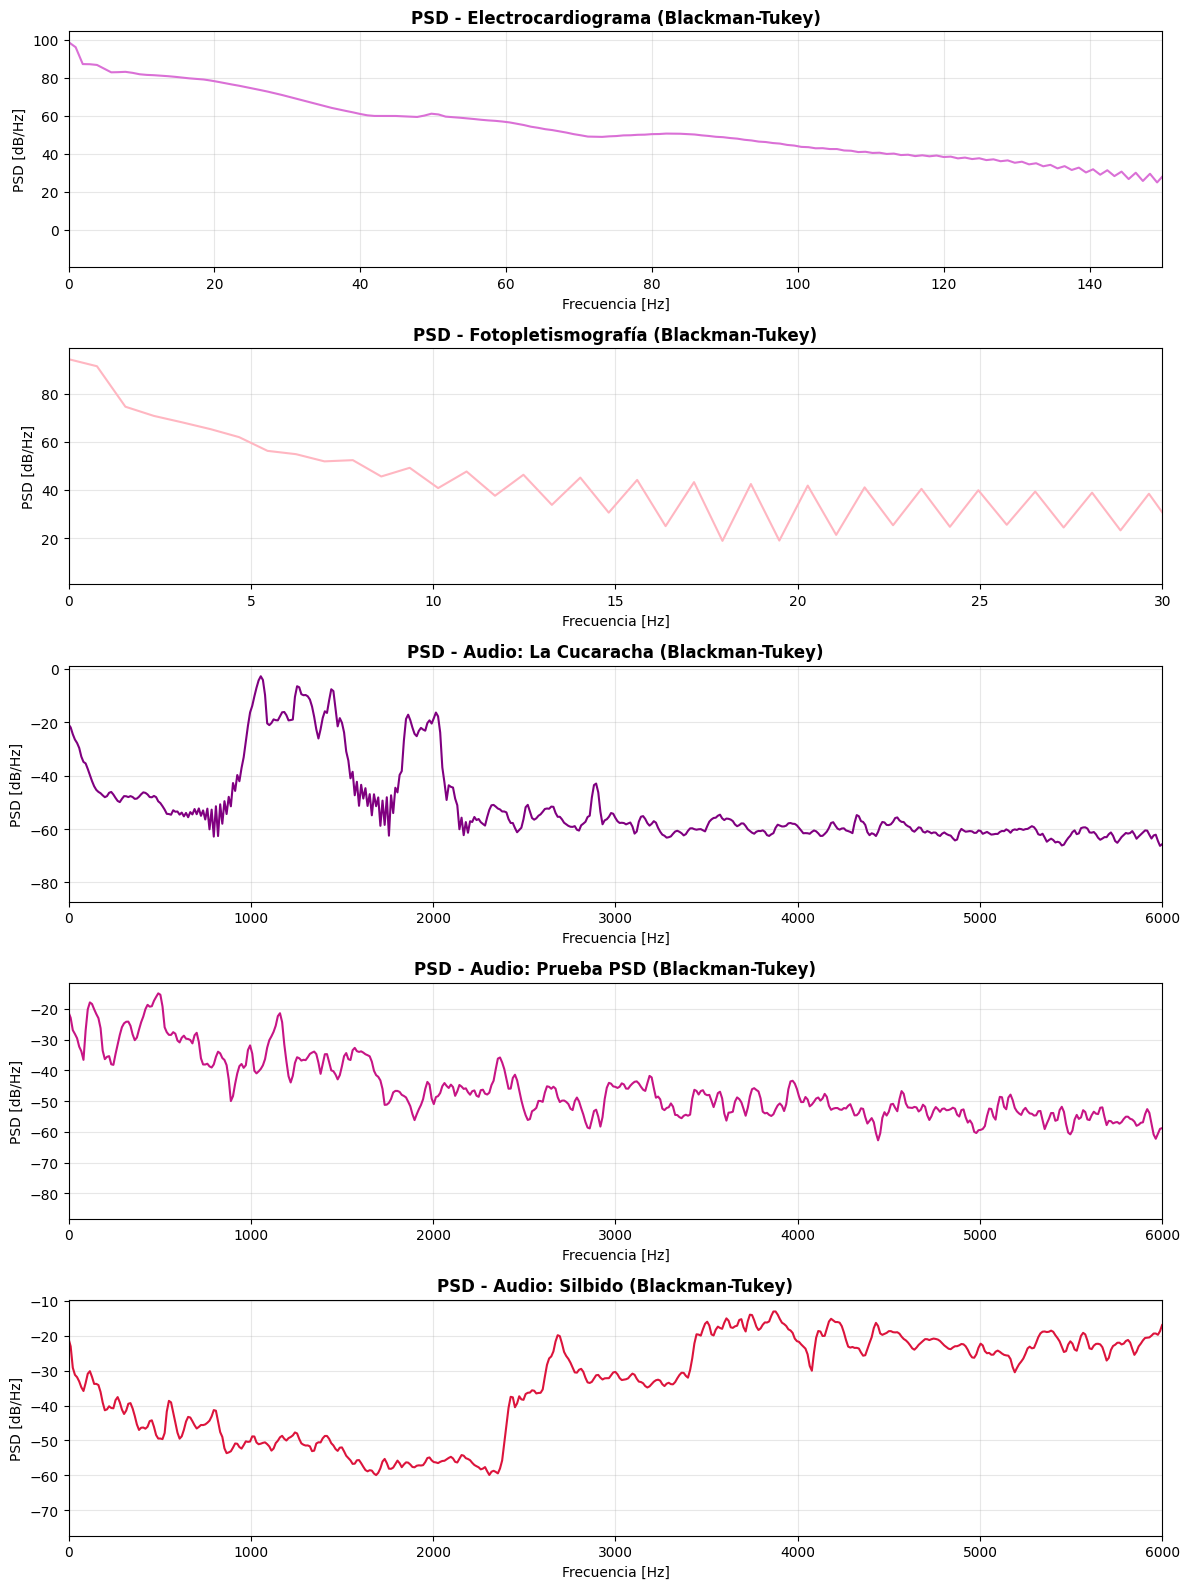

In [7]:
# Copio y pego lo del anterior y cambio la variiable
plt.figure(figsize=(12, 16))

# ECG
plt.subplot(5, 1, 1)
plt.plot(f_bt_ecg, 10 * np.log10(Pxx_bt_ecg), color='orchid')
plt.title('PSD - Electrocardiograma (Blackman-Tukey)', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 150])
plt.grid(True, alpha=0.3)

# PPG
plt.subplot(5, 1, 2)
plt.plot(f_bt_ppg, 10 * np.log10(Pxx_bt_ppg), color='lightpink')
plt.title('PSD - Fotopletismografía (Blackman-Tukey)', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 30])
plt.grid(True, alpha=0.3)

# Audio 1: La Cucaracha
plt.subplot(5, 1, 3)
plt.plot(f_bt_cuca, 10 * np.log10(Pxx_bt_cuca), color='purple')
plt.title('PSD - Audio: La Cucaracha (Blackman-Tukey)', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 6000])
plt.grid(True, alpha=0.3)

# Audio 2: Prueba PSD
plt.subplot(5, 1, 4)
plt.plot(f_bt_prue, 10 * np.log10(Pxx_bt_prue), color='mediumvioletred')
plt.title('PSD - Audio: Prueba PSD (Blackman-Tukey)', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 6000])
plt.grid(True, alpha=0.3)

# Audio 3: Silbido
plt.subplot(5, 1, 5)
plt.plot(f_bt_silb, 10 * np.log10(Pxx_bt_silb), color='crimson')
plt.title('PSD - Audio: Silbido (Blackman-Tukey)', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 6000])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Al observar los gráficos, se pueden percibir curvas que conservan picos de frecuencia muy filosos y definidos, en los audios como la cucaracha y el silbido, esto demuestra que este método tiene una excelente resolución espectral. El estimador elimina la variación del ruido usando la ventana de Hann pero se deja ver los picos reales de la señal, que como se encuentran a 60 dB por debajo del pico, se espera que esas oscilaciones sean propias del ruido, ya que a ese nivel de atenuación la energía útil de la señal es prácticamente despreciable.

**3. MÉTODO DE VENTNEO MODIFICADO:**

**CREACIÓN DE LA FUNCIÓN QUE CALCULA LA DPSD POR EL PERIODOGRAMA VENTANEADO**

In [8]:
def periodograma_ventaneado_psd(x, fs):
    # Defino una función que me calcule la PSD usando el Periodograma Modificado, os ea con alguna ventana.
    # A diferencia de Welch, acá  no corto la señal en pedacitos, proceso el registro completo de golpe.
    # x es el vector que contiene las muestras de la señal y fs es la frecuencia de muestreo de esa señal en particular.
    
    x_detrend = x - np.mean(x) # Volvemos a restar el promedio para eliminar la componente de continua (DC)
    
    # Calculo el periodograma usando  la ventana hann para suavizar los bordes de la señal en el tiempo y reducir el desparramo espectral.
    # Al no pasarle un tamaño de segmento corto (nperseg), usa el largo total de la señal.
    f, Pxx = sig.periodogram(x_detrend, fs=fs, window='hann')
    
    return f, Pxx

**LLAMO A LA FUNCIÓN PARA LAS 5 SEÑALES**

In [9]:
# Llamo a las dunciones agregandole el _per para no confundirme con las otras.
f_per_ecg, Pxx_per_ecg   = periodograma_ventaneado_psd(ecg_lead, fs_ecg)
f_per_ppg, Pxx_per_ppg   = periodograma_ventaneado_psd(ppg_raw, fs_ppg)
f_per_cuca, Pxx_per_cuca = periodograma_ventaneado_psd(wav_cucaracha, fs_audio1)
f_per_prue, Pxx_per_prue = periodograma_ventaneado_psd(wav_prueba, fs_audio2)
f_per_silb, Pxx_per_silb = periodograma_ventaneado_psd(wav_silbido, fs_audio3)


**GRÁFICO DE LAS PSDs DE LAS 5 SEÑALES**

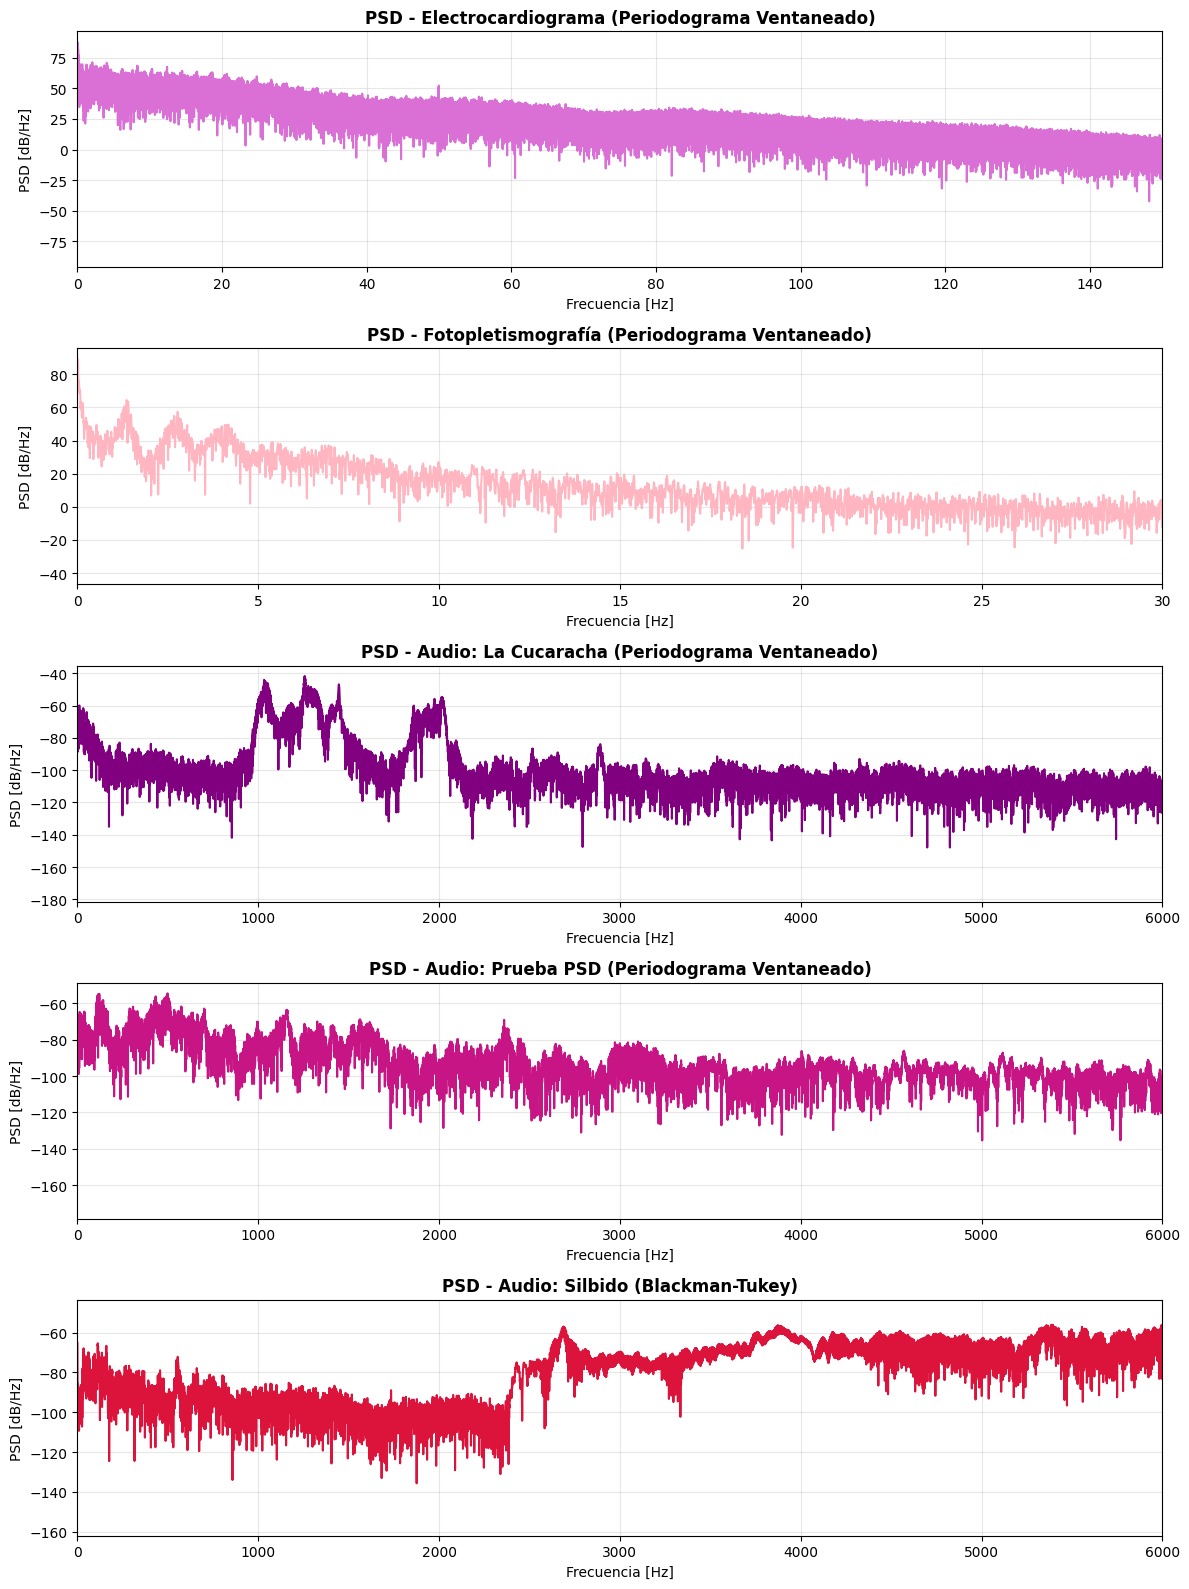

In [10]:
# Armamos una nueva figura independiente con los 5 gráficos del Periodograma
plt.figure(figsize=(12, 16))

# ECG
plt.subplot(5, 1, 1)
plt.plot(f_per_ecg, 10 * np.log10(Pxx_per_ecg), color='orchid')
plt.title('PSD - Electrocardiograma (Periodograma Ventaneado)', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 150])
plt.grid(True, alpha=0.3)

# PPG
plt.subplot(5, 1, 2)
plt.plot(f_per_ppg, 10 * np.log10(Pxx_per_ppg), color='lightpink')
plt.title('PSD - Fotopletismografía (Periodograma Ventaneado)', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 30])
plt.grid(True, alpha=0.3)

# Audio 1: La Cucaracha
plt.subplot(5, 1, 3)
plt.plot(f_per_cuca, 10 * np.log10(Pxx_per_cuca), color='purple')
plt.title('PSD - Audio: La Cucaracha (Periodograma Ventaneado)', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 6000])
plt.grid(True, alpha=0.3)

# Audio 2: Prueba PSD
plt.subplot(5, 1, 4)
plt.plot(f_per_prue, 10 * np.log10(Pxx_per_prue), color='mediumvioletred')
plt.title('PSD - Audio: Prueba PSD (Periodograma Ventaneado)', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 6000])
plt.grid(True, alpha=0.3)

# Audio 3: Silbido
plt.subplot(5, 1, 5)
plt.plot(f_per_silb, 10 * np.log10(Pxx_per_silb), color='crimson')
plt.title('PSD - Audio: Silbido (Blackman-Tukey)', fontweight='bold')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim([0, 6000])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Aclaración de la autora, yo:** Creo que llegado a este punto, hubiera sido preferible realizar en primer isntancia este experimento, para luego comprobar como los siguientes métodos mejoraron este espectro varianzudo, sin embargo, lo voy a intentar contrastar a continuación. 

Al observar los gráficos, del periodograma ventaneado, lo primero que se observa es el aspecto sumamente "greñudo" en las curvas de todas las señales. Como se procesa el registro completo de una sola vez, no se promedia nada, el ruido estocástico ingresa completamente al cálculo. Este se manifiesdta en una enorme y densa variación, es decir, dando una alta varianza.  

La ventaja de este estimador, consiste en ofrecer la máxima resolución espectral, se observa hasta el mínimo detalle. Además, al estar modificado con la ventana Hann, se frena el desparramo espectral. Sin embargo, no se logra solucionar su mayor defecto, y es que, es un estimador no consistente. O sea que, por más muestras que se le cargue al código, la fluctuación del ruido no se limpiará, lo que termina ensuciando el piso de ruido e infla el cálculo del ancho de banda. 

**Conclusiones**

Durante la clase se habló de un tema fundamental, el compromiso de diseño "trade-off", donde se mencionó que no existe un método perfecto, sino una especie de balanza donde se elije qué sacrificar en base a lo que se espera obtener. 

El periodograma ventaneado, da la máxima resolución espectral, picos hiper definidos, a costo de dar también la peor varianza, es un caos visual y todo el ruido sin filtrar. 


  El método de Welch, corta la señal en bloques solapados y los promedia, logrando la mínima varianza, o sea curvas súper suaves, pero da también la peor resolución espectral, los picos reales de la señal se ensanchan y difuminan. 


  Por último, el método de Blackman-Tukey, es un punto de equilibrio intermedio, ataca desde la función de autocorrelación, cortando los extremos inestables con una ventana, que suele ser de Hann, limpiando una gran cantidad de ruido, dando baja varianza, pero reteniendo los picos de frecuencia más definidos que los de Welch.

2) Realice una estimación del ancho de banda de cada señal y presente los resultados en un tabla para facilitar la comparación.

En el procesamiento digital de señales reales, el ancho de banda no puede medirse simplemente como la distancia entre la frecuencia máxima y mínima, debido a que las señales reales son estocásticas y ruidosas, y se extienden a lo largo de todo el espectro producto de su piso de ruido. Por lo tanto, se recurre al concepto de ancho de banda de potencia ocupada.

El profesor durante la clase, dijo que uno podía asumir un porcentaje donde esperaba encontrar potencia útil, asignando lo demás al ruido, en este caso se eligió hacer el criterio del 99%. Método que evalúa la densidad espectral de potencia en escala lineal, calculando su suma acumulada (Mariano le dice integral izquierda) partiendo desde la componente continua , o sae los $0\text{ Hz}$. 


El ancho de banda efectivo restante se descarta por considerarse ruido de fondo,

**DEFINIR LA FUNCIÓN QUE CALCULE EL ANCHO DE BANDA CON EL CRITERIO DEL 99%**

In [11]:
# Calculo del ancho de banda fijando un porcentaje de la potencia 99 o 95

def calcular_mi_bw_99(f, Pxx): #Calculo la suma acumulada de la potencia espectral usando np.cumsum. 
    # El otro 1% es ruido, fijo unumbral de la potencia en 99%
    potencia_acumulada = np.cumsum(Pxx)
    potencia_total = potencia_acumulada[-1] #Sé que el final es el 100%
    
    # Establezco el umbral calculando cuánto es el 99% de esa energía .
    umbral_99 = 0.99 * potencia_total
    
    #Si es pasabajo acumulo el porcentaje que quiero y lo de la derecha es ruido, como en este caso.
    #Si es pasabanada agarro una franja, me paro en el medio y me corro tipo 2.5 para un lado y 2.5 para el otro
    #Busco donde se pasa ese punto ya freno, quiero encontrar un índice 
    # Busco el primer lugar donde la suma acumulada empata o supera mi umbral del 99%.
    indice_99 = np.where(potencia_acumulada >= umbral_99)[0][0]  

    
    return f[indice_99] #Acá me había dado cualquier cosa, porque había devuelto la potencia jaja me ayudó Hernán diciéndome que lo que en realidad
    #quería devolver era la frecuencia y no la potencia. Update, me tiró como 40 errores, porque al principio lo definí como f_ecg[indice_99], hasta 
    #que me di cuenta que necesitaba el f solo. 
    

    #Para que la potencia sea unitaria, debo escalar por std(x), o sea desvío estandar de la sñeal
    #varianza.

**LLAMO A LA FUNCIÓN PARA LOS DISTINTOS MÉTODOS Y SEÑALES**

In [12]:
bw_welch_ecg  = calcular_mi_bw_99(f_ecg, Pxx_ecg)
bw_welch_ppg  = calcular_mi_bw_99(f_ppg, Pxx_ppg)
bw_welch_cuca = calcular_mi_bw_99(f_cuca, Pxx_cuca)
bw_welch_prue = calcular_mi_bw_99(f_prue, Pxx_prue)
bw_welch_silb = calcular_mi_bw_99(f_silb, Pxx_silb)


bw_bt_ecg  = calcular_mi_bw_99(f_bt_ecg, Pxx_bt_ecg)
bw_bt_ppg  = calcular_mi_bw_99(f_bt_ppg, Pxx_bt_ppg)
bw_bt_cuca = calcular_mi_bw_99(f_bt_cuca, Pxx_bt_cuca)
bw_bt_prue = calcular_mi_bw_99(f_bt_prue, Pxx_bt_prue)
bw_bt_silb = calcular_mi_bw_99(f_bt_silb, Pxx_bt_silb)


bw_per_ecg  = calcular_mi_bw_99(f_per_ecg, Pxx_per_ecg)
bw_per_ppg  = calcular_mi_bw_99(f_per_ppg, Pxx_per_ppg)
bw_per_cuca = calcular_mi_bw_99(f_per_cuca, Pxx_per_cuca)
bw_per_prue = calcular_mi_bw_99(f_per_prue, Pxx_per_prue)
bw_per_silb = calcular_mi_bw_99(f_per_silb, Pxx_per_silb)


In [13]:
# Le pasé el código a la IA y le pefí que me ayudara a imprimirlo en formato tabla:
    
# Imprimo el encabezado acomodando los anchos de las columnas.
print(f"\n{'Señal Analizada':<26} | {'BW Welch (99%)':<16} | {'BW Blackman-T. (99%)':<22} | {'BW Periodog. Vent (99%)':<24}")
print("-" * 101) # Esto mete una línea dicisora. 
print(f"{'Electrocardiograma (ECG)':<26} | {bw_welch_ecg:<12.2f} Hz | {bw_bt_ecg:<19.2f} Hz | {bw_per_ecg:<21.2f} Hz")
print(f"{'Fotopletismografía (PPG)':<26} | {bw_welch_ppg:<12.2f} Hz | {bw_bt_ppg:<19.2f} Hz | {bw_per_ppg:<21.2f} Hz")
print(f"{'Audio: La Cucaracha':<26} | {bw_welch_cuca:<12.2f} Hz | {bw_bt_cuca:<19.2f} Hz | {bw_per_cuca:<21.2f} Hz")
print(f"{'Audio: Prueba PSD':<26} | {bw_welch_prue:<12.2f} Hz | {bw_bt_prue:<19.2f} Hz | {bw_per_prue:<21.2f} Hz")
print(f"{'Audio: Silbido':<26} | {bw_welch_silb:<12.2f} Hz | {bw_bt_silb:<19.2f} Hz | {bw_per_silb:<21.2f} Hz")


Señal Analizada            | BW Welch (99%)   | BW Blackman-T. (99%)   | BW Periodog. Vent (99%) 
-----------------------------------------------------------------------------------------------------
Electrocardiograma (ECG)   | 32.23        Hz | 25.37               Hz | 26.93                 Hz
Fotopletismografía (PPG)   | 5.47         Hz | 1.56                Hz | 1.39                  Hz
Audio: La Cucaracha        | 2015.62      Hz | 2015.13             Hz | 2019.00               Hz
Audio: Prueba PSD          | 2636.72      Hz | 2460.34             Hz | 2379.67               Hz
Audio: Silbido             | 6644.53      Hz | 6654.63             Hz | 6668.67               Hz


 Al observar los resultados presentes en la tabla, se pueden elaborar conclusiones de acuerde a la naturaleza de las señales analizadas.

**1. Contraste Físico de las Señales Biomédicas vs las de Audio**

En primer lugar se percibe una drástica diferechia entre los anchos de banda, las señales biomédicas (ECG y PPG) presentan un ancho de banda muy corto. 

El PPG es más lento, concentrando su información útil debajo de los $5\text{ Hz}$, esto parecería lógico, puesto que mide variaciones de volumen sanguíneo por pulso. 

El ECG registra actividad eléctrica cardíaca, los complejos QRS son más rápidos, extiende su energía útil hasta $25\text{ Hz} - 32\text{ Hz}$. 

Las señales de audio, por su parte, saltan a escalas de miles de Hertz, siendo el silbido la  de mayor frecuencia, siendo su ancho de banda $6.6\text{ kHz}$.

**2. La influencia de los estimadores en el cálculo del $BW_{99\%}$**

Ahora se procederá a comparar los tres métodos realizados, (Welch - Blackmann - Periodograma modificado) para una misma señal.

El periodograma ventaneado deja un piso de ruido alto y con alta varianza. En señales con mucho ruido esos picos se meten directo sumando potencia falsa, por lo que se esperaría que sea mayor a los demás, sin embargo en algunas de las señales, ocurre lo contrario, observándose un comportamiento atípico. Puede deberse que la señal posee una estructura compleja, que tiene valles profundos que conserva gracias a su alta resolución, mientras que los otros métodos suavizan ensanchando los picos y elevando el nivel de valles, por ello tarda más en alcanzar el ubral. 

El método de Welch en señales lentas como las biomédicas da un ancho de banda notablemente mayor ($5.47\text{ Hz}$) en comparación con Blackman-Tukey ($1.56\text{ Hz}$) y el Periodograma ($1.39\text{ Hz}$ , esto es consecuencia del ensanchamiento por la baja resolución. Cuando se corta la señal en bloques y se promedia , baja el ruid y los picos espectrales se vuelven más gorditos, perdiendo resolución. En una  señal que tiene ancho de banda chiquito, el engrosamiento artificial.

Blackman se mantuvo balanceado, logrando valores estables, removió el ruio evitando inflar tanto el ancho, ya que tiene alta resolución. 

Los resultados numéricos pueden confirmar el mencionado "trade - off " en el procesamiento digital de señales.  Para medir precisamente el ancho de banda efectivo en señales biomédicas, el método de Blackman  hasta el periodograma ventaneado, parecen prevenir la distorsión por pérdida de resolución. Sin embargo, en entornos ruidosos, el método de Weclh da la mayor estabilidad estadística a pesar del ensanchamiento espectral. 

**Bonus:**

💎 Proponga algún tipo de señal que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.

ACLARACIÓN: Bueno, esto me llevó todo un proceso larguísimo pre aprendí mucho. Me encantó esta parte. Procedo a redactar el proceso en primera persona. 

En primer lugar, elegí una señal, en este caso el ruido del violín de la introducción del Lago de los Cisnes de Tchaikovski (https://www.youtube.com/watch?v=cwTctSxuTIs), porque es mi musical favorito y quería ver cómo se vería el espectro de esa parte, en realidad quería probar con la segunda parte donde suena mucho más grave para ver si varíaban las frecuencias al compararlos, pero me quedé con solo la primer parte para no hacer el trabajo muy largo.

Luego me pirateé el video de youtube descargándomelo y lo recorté con un programa que tenía en la compu, después como lo tenía en un formatgo raro de M4A, tuve que subirlo a una página (https://cloudconvert.com/m4a-to-wav) para que me lo pasara a .wav, que es el que el profesor nos enseñó.  

**DIGITALIZO Y SUBO LA SEÑAL**

In [19]:
from scipy.io import wavfile
# Uso wavfile.read que viene en SciPy y no requiere librerías raras que me decía la IA que usara. 
fs_bonus, datos_bonus = wavfile.read('audio_bonus.wav')

# Normalizo la amplitud para que quedee -1 y 1 como las otras señales.
if datos_bonus.dtype == np.int16:
    audio_bonus_raw = datos_bonus / 32768.0
elif datos_bonus.dtype == np.int8:
    audio_bonus_raw = (datos_bonus / 128.0) - 1.0
else:
    audio_bonus_raw = datos_bonus

# Acá como no sabía cómo era el audio, la IA me agregó esta parte, donde si viene por dos canales, te quedás con solo uno. 
if len(audio_bonus_raw.shape) > 1:
    audio_bonus = audio_bonus_raw[:, 0]
else:
    audio_bonus = audio_bonus_raw

**HAGO LA DSP DE LA SEÑAL CON LOS TRES MÉTODOS**

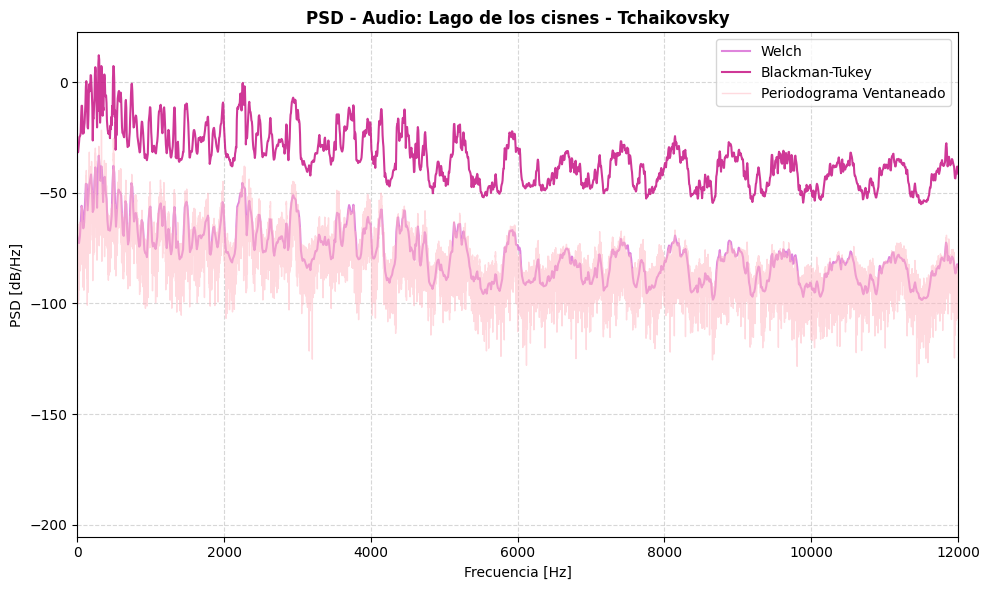

In [26]:
# Método de Welch.
f_welch_bon, Pxx_welch_bon = sig.welch(audio_bonus, fs=fs_bonus, nperseg=4096)

# Método de Blackman-Tukey.
f_bt_bon, Pxx_bt_bon = blackman_tukey_psd(audio_bonus, fs_bonus, max_lag=4096)

# Método de Periodograma Ventaneado.
f_per_bon, Pxx_per_bon = periodograma_ventaneado_psd(audio_bonus, fs_bonus)


# GRAFIO LOS ESPECTROS DEL VIOLÍN.

plt.figure(figsize=(10, 6))
plt.plot(f_welch_bon, 10 * np.log10(Pxx_welch_bon), label='Welch', alpha=0.85, linewidth=1.5, color='orchid')
plt.plot(f_bt_bon, 10 * np.log10(Pxx_bt_bon), label='Blackman-Tukey', alpha=0.85, linewidth=1.5, color='mediumvioletred')
plt.plot(f_per_bon, 10 * np.log10(Pxx_per_bon), label='Periodograma Ventaneado', alpha=0.5, linewidth=1, color='lightpink')
plt.title('PSD - Audio: Lago de los cisnes - Tchaikovsky', fontsize=12, fontweight='bold')
plt.xlabel('Frecuencia [Hz]', fontsize=10)
plt.ylabel('PSD [dB/Hz]', fontsize=10)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(loc='upper right')
plt.xlim(0, 12000) 

plt.tight_layout()
plt.show()

**CÁLCULO EL ANCHO DE BANDA EFECTIVO (99%)**

In [28]:
bw_welch_bon = calcular_mi_bw_99(f_welch_bon, Pxx_welch_bon)
bw_bt_bon    = calcular_mi_bw_99(f_bt_bon, Pxx_bt_bon)
bw_per_bon   = calcular_mi_bw_99(f_per_bon, Pxx_per_bon)

print(f"{'PSD - Audio: Lago de los cisnes - Tchaikovsky':<26} | {bw_welch_bon:<12.2f} Hz | {bw_bt_bon:<19.2f} Hz | {bw_per_bon:<21.2f} Hz")

PSD - Audio: Lago de los cisnes - Tchaikovsky | 4136.72      Hz | 4136.21             Hz | 4135.50               Hz


A diferencia de las señales anteriores, el cálculo del ancho de banda efectivo ($BW_{99\%}$) se estabiliza de forma casi-unánime alrededor de los $4135\text{ Hz} - 4136\text{ Hz}$ para los tres métodos vistos. La energía útil del violín, se concentra por debajo de los $4.1\text{ kHz}$. Pasada esa frecuencia, la energía cae abruptamente hacia el piso de ruido.

Salta a la vista que  la curva de Blackman-Tukey mantiene la misma forma y picos que Welch y el Periodograma, pero se encuentra corrida hacia arriba, o sea registra más $\text{dB/Hz}$ . 

Nuevamente, se nota que el Periodograma Ventaneado aporta el máximo detalle de picos con un nivel de ruido de fondo  que llega a tocar los $-130\text{ dB}$, aproximadamente. El método de Welch por su parte suaviza de forma óptima para un análisis estadístico limpio, pero ensancha las componentes. 
El análisis de este audio real ratifica el compromiso de diseño estudiado, en este caso, se requiere una buena resolución espectral para no confundir el ruido del violín con lo demás presente en la señal. 